In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

In [2]:
data_root = "../../../../../data/datasets/MNIST/"
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
train_dataset = datasets.MNIST(root=data_root, train=True, download=False, transform=transforms.ToTensor())
validation_dataset = datasets.MNIST(root=data_root, train=False, download=False, transform=transforms.ToTensor())

train_loader = DataLoader(
  dataset=train_dataset,
  batch_size=batch_size,
  shuffle=True
)

validation_loader = DataLoader(
  dataset=validation_dataset,
  batch_size=batch_size,
  shuffle=False
)

In [4]:
images, labels = next(iter(train_loader))
in_features = images.shape[2] * images.shape[3]
print(images.shape)
print(labels.shape)
print(labels)

num_classes = len(train_dataset.classes)
print(num_classes)

torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor([2, 4, 5, 0, 6, 8, 4, 2, 4, 8, 6, 9, 6, 4, 7, 0, 3, 7, 7, 2, 5, 8, 0, 4,
        0, 1, 3, 5, 1, 1, 1, 6])
10


In [5]:
class MLP(nn.Module):
  def __init__(self, in_features, hidden_dim1, hidden_dim2, out_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(in_features=in_features, out_features=hidden_dim1),
      nn.ReLU(),
      nn.Linear(in_features=hidden_dim1, out_features=hidden_dim2),
      nn.ReLU(),
      nn.Linear(in_features=hidden_dim2, out_features=out_features)
    )
  
  def forward(self, x):
    return self.model(x)

In [6]:
model = MLP(in_features=784, hidden_dim1=512, hidden_dim2=512, out_features=num_classes)

In [7]:
torch.manual_seed(42)
image_dummy = torch.randn(1, 1, 28, 28)
x_train_dummy = image_dummy.view(image_dummy.shape[0], -1)
print(x_train_dummy.shape)

x_train = images.view(images.shape[0], -1)
print(x_train.shape)

model.train()
y_train_dummy_logits = model(x_train_dummy)
print("y_train_dummy_logits", y_train_dummy_logits)

torch.Size([1, 784])
torch.Size([32, 784])
y_train_dummy_logits tensor([[-0.0377,  0.0220, -0.0307, -0.0639,  0.0577,  0.0225, -0.0440, -0.0405,
         -0.0450, -0.1753]], grad_fn=<AddmmBackward0>)


In [8]:
# Accuracy calculation option 1
y_train_prob_dummy = torch.sigmoid(y_train_dummy_logits)
print("y_train_prob_dummy", y_train_prob_dummy)

y_train_pred_index_dummy = torch.argmax(y_train_prob_dummy, dim=1)
print("y_train_pred_index_dummy", y_train_pred_index_dummy)

y_train_prob_dummy tensor([[0.4906, 0.5055, 0.4923, 0.4840, 0.5144, 0.5056, 0.4890, 0.4899, 0.4888,
         0.4563]], grad_fn=<SigmoidBackward0>)
y_train_pred_index_dummy tensor([4])


In [9]:
# Accuracy calculation option 2
y_train_pred_index_dummy = y_train_dummy_logits.argmax(dim=1)
print("y_train_pred_index_dummy", y_train_pred_index_dummy)

y_train_pred_index_dummy tensor([4])


In [10]:
# Compute accuracy option 3
y_val, y_train_pred_index_dummy = torch.max(y_train_prob_dummy, dim=1)
# print("y_val", y_val)
print("y_pred", y_train_pred_index_dummy)
# running_correct += (y_train_pred_index_dummy == y_val).sum().item()

y_pred tensor([4])


In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [12]:
def train():
  model.train()

  running_loss = 0
  running_correct = 0

  for (X, y) in train_loader:
    X = X.view(X.shape[0], -1)
    y_logits = model(X)
    # print("y_logits", y_logits)
    
    # Compute loss
    loss = loss_fn(y_logits, y)
    running_loss += loss.item()
    
    # Compute accuracy

    y_pred = y_logits.argmax(dim=1)
    correct = torch.sum(y_pred==y).item()
    running_correct += correct
    
    # Backpropagation
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

  loss = running_loss / len(train_loader.dataset)
  accuracy = running_correct / len(train_loader.dataset)
  return loss, accuracy

In [13]:
loss, accuracy = train()

In [14]:
def val():
  model.eval()
  running_loss = 0
  running_correct = 0
  
  with torch.inference_mode():
    for(X, y) in validation_loader:
      # print("y", y)
      X = X.view(X.shape[0], -1)
      y_logits = model(X)

      loss = loss_fn(y_logits, y)
      
      # Compute Accuracy
      # y_pred = y_logits.argmax(dim=1)
      
      prob = nn.functional.softmax(y_logits, dim=1)
      y_pred = prob.argmax(dim=1)

      correct = torch.sum(y_pred == y).item()

      running_loss += loss.item()
      running_correct += correct

  loss = running_loss / len(validation_loader.dataset)
  correct = running_correct / len(validation_loader.dataset)
  return loss, correct

In [15]:
validation_loss, validation_accuracy = val()

print(validation_loss, validation_accuracy)

0.012233894305303692 0.8914


In [16]:
num_epochs = 2

In [17]:
train_loss_history = []
validation_loss_history = []

train_accuracy_history = []
validation_accuracy_history = []

print("Strat Training...")
for epoch in range(num_epochs):
  train_loss, train_accuracy = train()
  validation_loss, validation_accuracy = val()

  
  print(f"epoch: {epoch} | train_loss: {train_loss:.4f}, train_accuracy: {train_accuracy:.4f} | validation_loss: {validation_loss:.4f}, validation_accuracy: {validation_accuracy:.4f}")
  train_loss_history.append(train_loss)
  validation_loss_history.append(validation_loss)
  
  train_accuracy_history.append(train_accuracy)
  validation_accuracy_history.append(validation_accuracy)

Strat Training...
epoch: 0 | train_loss: 0.0110, train_accuracy: 0.9001 | validation_loss: 0.0093, validation_accuracy: 0.9156
epoch: 1 | train_loss: 0.0091, train_accuracy: 0.9167 | validation_loss: 0.0081, validation_accuracy: 0.9257


Text(0.5, 1.0, 'Accuracy Curve')

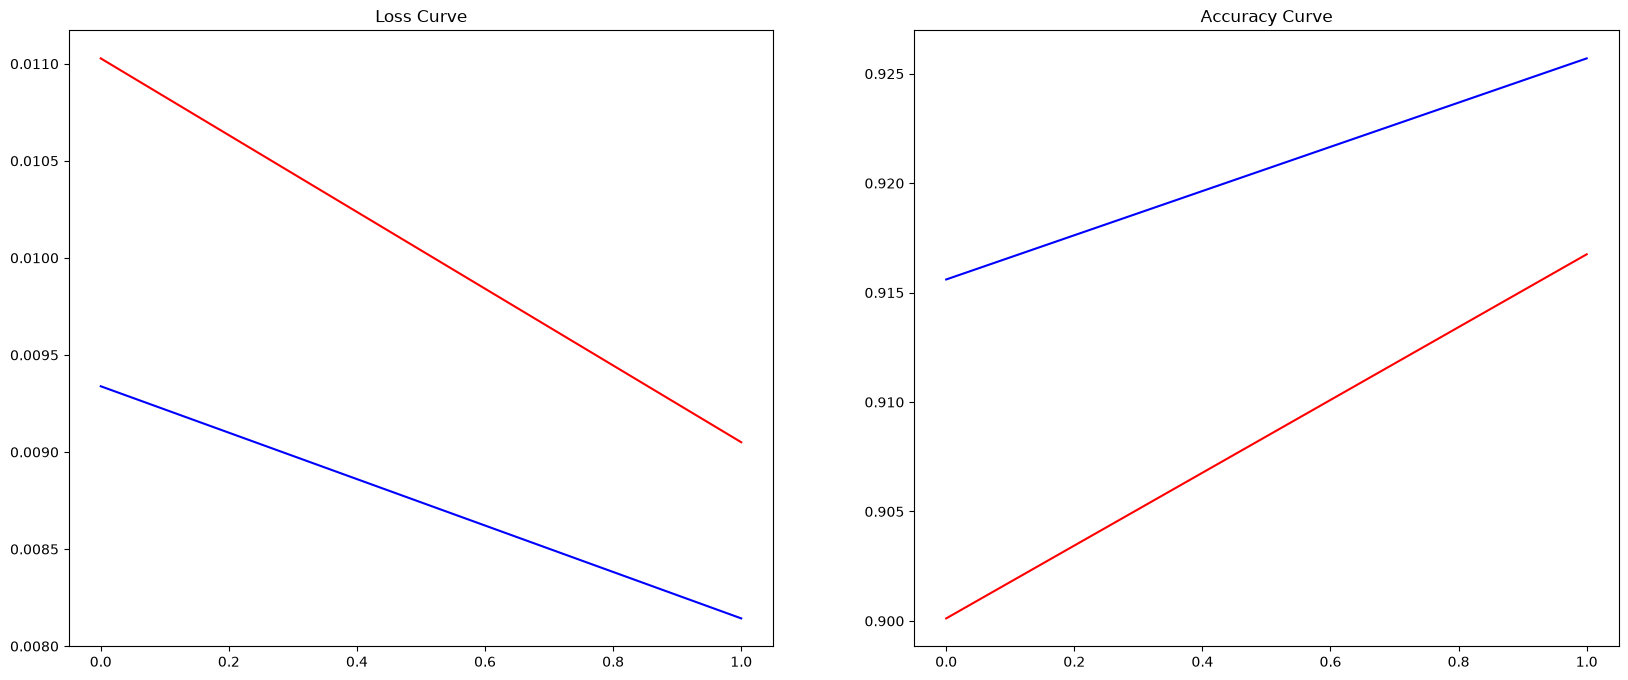

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=[20,8])
plt.subplot(121)
plt.plot(train_loss_history,'r')
plt.plot(validation_loss_history,'b')
plt.title("Loss Curve")

plt.subplot(122)
plt.plot(train_accuracy_history,'r')
plt.plot(validation_accuracy_history,'b')
plt.title("Accuracy Curve")

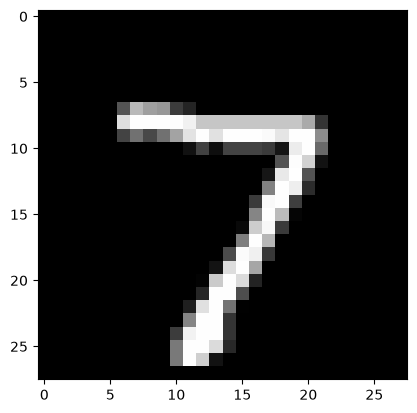

In [20]:
images, labels = next(iter(validation_loader))
plt.imshow(images[0][0], cmap='gray')